In [ ]:
# this is the final IMPORTANT code used to train can calcualte metrices

In [ ]:
# Verify GPU availability and install the latest Ultralytics release with visualization dependencies
!nvidia-smi
!pip install -q ultralytics matplotlib seaborn pandas

Thu Aug 20 16:50:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import zipfile
import os
from google.colab import files

print("Please upload your dataset zip file (e.g., final_yolo_model_dataset.zip):")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

# Extract directly into /content runtime
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content')

print(f"Successfully extracted {zip_name} to /content!")

Please upload your dataset zip file (e.g., final_yolo_model_dataset.zip):


Saving final_yolo_model_dataset.zip to final_yolo_model_dataset.zip
Successfully extracted final_yolo_model_dataset.zip to /content!


In [ ]:
import yaml

# Automatically set up data.yaml with optimized absolute paths
yaml_content = {
    'path': '/content/final_yolo_model_dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'bhat',
        1: 'dal',
        2: 'sabji'
    }
}

yaml_path = '/content/final_yolo_model_dataset/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(f"data.yaml configured successfully at {yaml_path}!")

data.yaml configured successfully at /content/final_yolo_model_dataset/data.yaml!


In [ ]:
from ultralytics import YOLO

# Load lightweight YOLO11 Nano Segmentation model
model = YOLO("yolo11n-seg.pt")

# Fine-tuned training pipeline engineered for small dataset sizes (~300 images)
results = model.train(
    data="/content/final_yolo_model_dataset/data.yaml",
    task="segment",
    epochs=120,
    imgsz=640,
    batch=16,
    workers=4,
    patience=25,

    # Optimization strategy
    optimizer="AdamW",
    lr0=0.0015,
    lrf=0.01,
    cos_lr=True,
    weight_decay=0.0005,

    # Strategic augmentation suite tailored for food plate segmentation
    augment=True,
    hsv_h=0.015,
    hsv_s=0.6,
    hsv_v=0.4,
    degrees=15.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.0001,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,

    # Output tracking
    project="/content/runs/segment",
    name="nepali_plate_optimized_run",
    exist_ok=True,
    plots=True
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/final_yolo_model_dataset/data.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, 

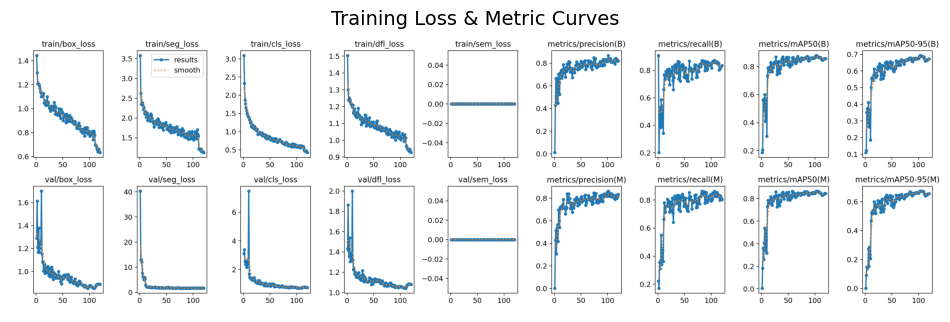

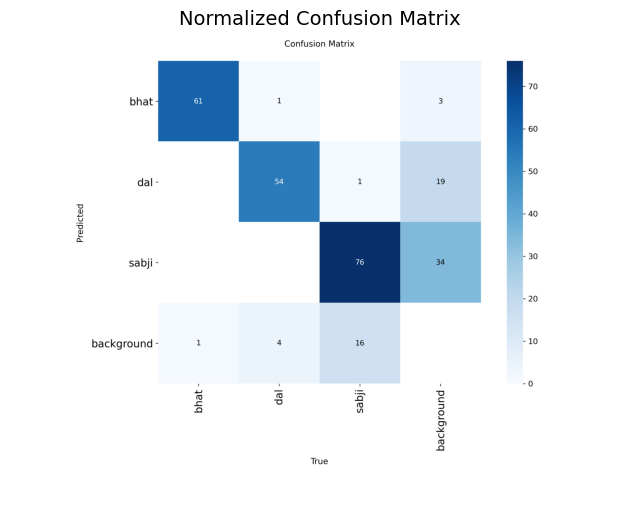

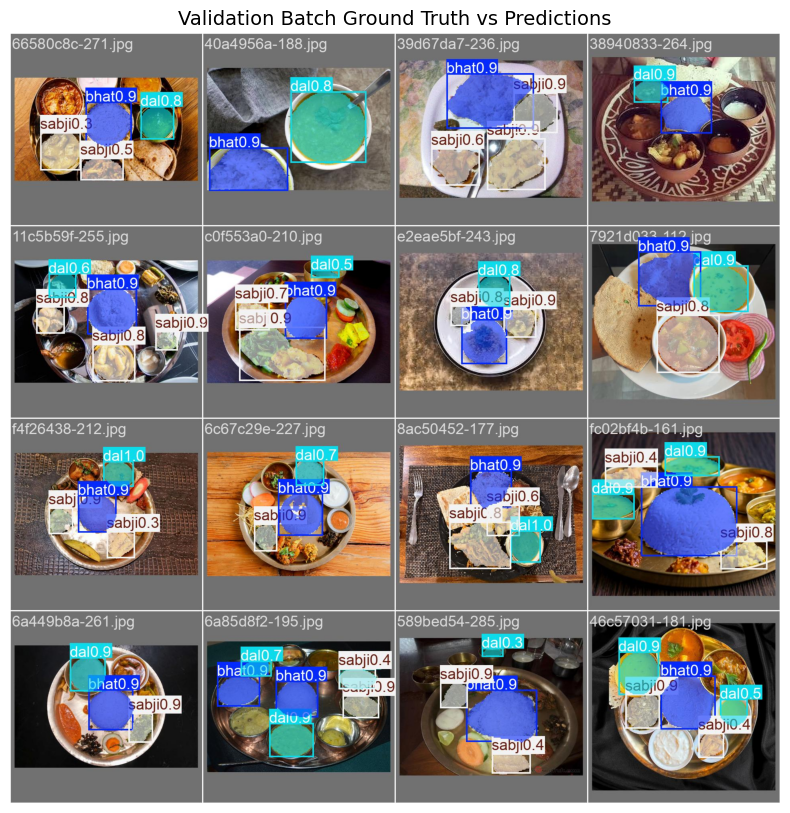

In [ ]:
import matplotlib.pyplot as plt
import cv2
from PIL import Image

run_dir = "/content/runs/segment/nepali_plate_optimized_run"

# Display training loss and metric curves
results_png = os.path.join(run_dir, "results.png")
if os.path.exists(results_png):
    plt.figure(figsize=(12, 8))
    plt.imshow(Image.open(results_png))
    plt.axis("off")
    plt.title("Training Loss & Metric Curves", fontsize=14)
    plt.show()

# Display Confusion Matrix
confusion_png = os.path.join(run_dir, "confusion_matrix.png")
if os.path.exists(confusion_png):
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(confusion_png))
    plt.axis("off")
    plt.title("Normalized Confusion Matrix", fontsize=14)
    plt.show()

# Display Validation Predictions
val_batch = os.path.join(run_dir, "val_batch0_pred.jpg")
if os.path.exists(val_batch):
    plt.figure(figsize=(10, 10))
    plt.imshow(Image.open(val_batch))
    plt.axis("off")
    plt.title("Validation Batch Ground Truth vs Predictions", fontsize=14)
    plt.show()

FINAL MODEL ACCURACY METRICS (Last Epoch):
Box Precision (B):    0.8210
Box Recall (B):       0.8344
Box mAP50 (B):        0.8578
Box mAP50-95 (B):     0.6736
------------------------------------------------------------
Mask Precision (M):   0.8331
Mask Recall (M):      0.8026
Mask mAP50 (M):       0.8465
Mask mAP50-95 (M):    0.6562


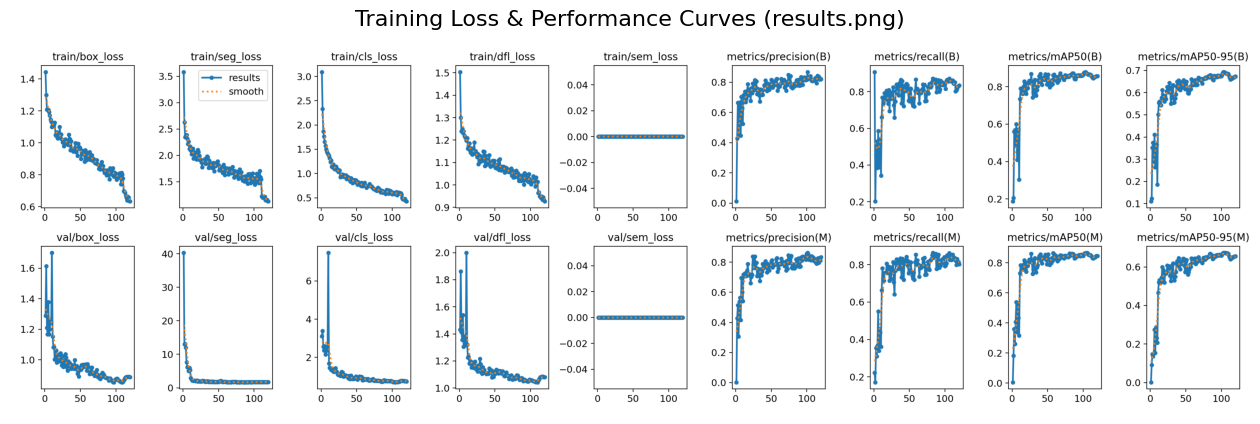

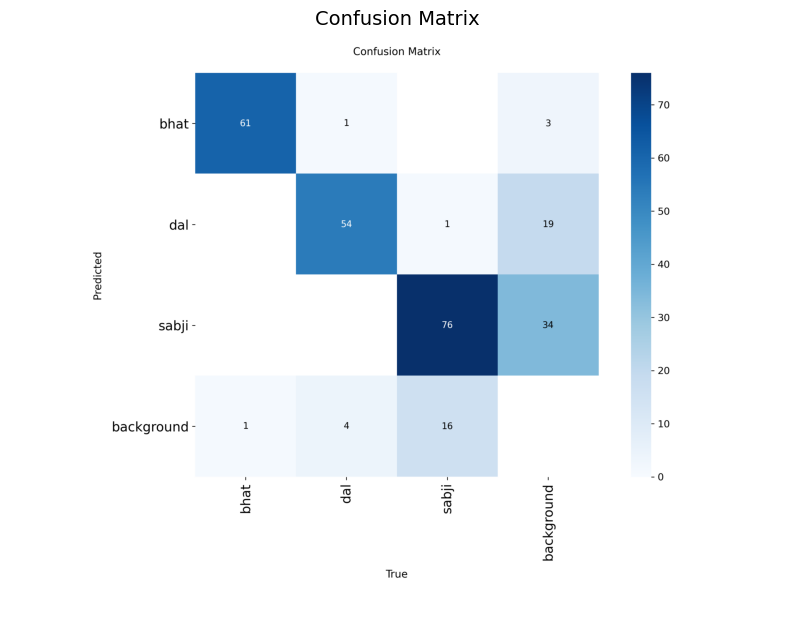

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

run_dir = "/content/runs/segment/nepali_plate_optimized_run"

# 1. PRINT NUMERICAL METRICS TABLE
results_csv = os.path.join(run_dir, "results.csv")

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # Strip extra spaces from column names

    print("="*60)
    print("FINAL MODEL ACCURACY METRICS (Last Epoch):")
    print("="*60)

    # Extract latest performance metrics
    last_epoch = df.iloc[-1]

    # Bounding Box / Detection Metrics
    if 'metrics/precision(B)' in df.columns:
        print(f"Box Precision (B):    {last_epoch['metrics/precision(B)']:.4f}")
        print(f"Box Recall (B):       {last_epoch['metrics/recall(B)']:.4f}")
        print(f"Box mAP50 (B):        {last_epoch['metrics/mAP50(B)']:.4f}")
        print(f"Box mAP50-95 (B):     {last_epoch['metrics/mAP50-95(B)']:.4f}")
        print("-" * 60)

    # Mask / Segmentation Metrics
    if 'metrics/precision(M)' in df.columns:
        print(f"Mask Precision (M):   {last_epoch['metrics/precision(M)']:.4f}")
        print(f"Mask Recall (M):      {last_epoch['metrics/recall(M)']:.4f}")
        print(f"Mask mAP50 (M):       {last_epoch['metrics/mAP50(M)']:.4f}")
        print(f"Mask mAP50-95 (M):    {last_epoch['metrics/mAP50-95(M)']:.4f}")
        print("="*60)

# 2. DISPLAY TRAINING & VALIDATION GRAPH (results.png)
results_png = os.path.join(run_dir, "results.png")
if os.path.exists(results_png):
    plt.figure(figsize=(16, 10))
    plt.imshow(Image.open(results_png))
    plt.axis("off")
    plt.title("Training Loss & Performance Curves (results.png)", fontsize=16, pad=12)
    plt.show()

# 3. DISPLAY ADDITIONAL EVALUATION CHARTS
additional_plots = [
    ("confusion_matrix.png", "Confusion Matrix"),
    ("PR_curve.png", "Precision-Recall Curve"),
    ("F1_curve.png", "F1 Confidence Curve")
]

for file_name, title in additional_plots:
    img_path = os.path.join(run_dir, file_name)
    if os.path.exists(img_path):
        plt.figure(figsize=(10, 8))
        plt.imshow(Image.open(img_path))
        plt.axis("off")
        plt.title(title, fontsize=14, pad=10)
        plt.show()

In [ ]:
import os
from google.colab import files

# Path to the best weights generated from your training run
model_path = "/content/runs/segment/nepali_plate_optimized_run/weights/best.pt"

if os.path.exists(model_path):
    print("Downloading best.pt to your local machine...")
    files.download(model_path)
else:
    print(f"Model file not found at {model_path}. Ensure training completed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO  # Load YOLO library

# Load lightweight YOLO11 Nano Segmentation model
model = YOLO("yolo11n-seg.pt")  # Load pre-trained weights

# Fine-tuned training pipeline engineered for small dataset sizes (~300 images)
results = model.train(  # Start training process
    data="/content/final_yolo_model_dataset/data.yaml",  # Dataset config path
    task="segment",  # Instance segmentation task
    epochs=120,  # Max training cycles
    imgsz=640,  # Image resolution
    batch=16,  # Batch size
    workers=4,  # CPU data loaders
    patience=25,  # Early stopping limit

    # Optimization strategy
    optimizer="AdamW",  # AdamW optimizer
    lr0=0.0015,  # Initial learning rate
    lrf=0.01,  # Final learning rate ratio
    cos_lr=True,  # Cosine learning schedule
    weight_decay=0.0005,  # Weight decay penalty

    # Strategic augmentation suite tailored for food plate segmentation
    augment=True,  # Enable augmentations
    hsv_h=0.015,  # Hue variation
    hsv_s=0.6,  # Saturation variation
    hsv_v=0.4,  # Brightness variation
    degrees=15.0,  # Rotation angle
    translate=0.1,  # Image translation shift
    scale=0.5,  # Zoom scale factor
    shear=2.0,  # Shear distortion angle
    perspective=0.0001,  # Perspective shift angle
    flipud=0.0,  # Vertical flip chance
    fliplr=0.5,  # Horizontal flip chance
    mosaic=1.0,  # 4-image mosaic mix
    mixup=0.1,  # Image mixup probability
    copy_paste=0.1,  # Mask copy-paste chance

    # Output tracking
    project="/content/runs/segment",  # Save folder location
    name="nepali_plate_optimized_run",  # Run folder name
    exist_ok=True,  # Overwrite existing folder
    plots=True  # Generate metric plots
)